# Joint Regression — k_min, k_max, sigma

Single ResNet50 model predicting all three fractal parameters simultaneously.

Key improvements over the loss benchmark:
- **Uniform k_min sampling**: k_min drawn first from U[1,62], then k_max ~ U[k_min+2, 64] — eliminates the severe low-tail bias
- **Global image normalisation**: p1/p99 percentiles preserve inter-image contrast (sigma signal)
- **Joint 3-output head with Sigmoid**: one model, one training run, bounded output
- **Equal-weight normalised RMSE**: all targets normalised to [0,1] before loss

In [9]:
# Cell 1 — Imports & config
from pathlib import Path
import json, time, sys
import numpy as np
import h5py
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import multiprocessing as mp

# ── Paths ──────────────────────────────────────────────────────────────────
PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / 'src').exists() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.insert(0, str(PROJECT_ROOT / 'src'))
sys.path.insert(0, str(PROJECT_ROOT / 'src' / 'pyFC_lib'))

DATA_FILE  = PROJECT_ROOT / 'data' / 'raw' / 'uniform_kmin_128x128_100000.h5'
OUTPUT_DIR = PROJECT_ROOT / 'outputs' / 'comparison' / 'joint_regression'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ── Hyperparams ────────────────────────────────────────────────────────────
SEED        = 42
N_IMAGES    = 100_000
IMG_SIZE    = 128
EPOCHS      = 50
BATCH_SIZE  = 32
LR          = 1e-4
NUM_WORKERS = max(1, mp.cpu_count() - 1)
GEN_BATCH   = 500          # images per write-batch during generation
BETA        = -5.0 / 3.0
MEAN_VAL    = 1.0

# ── Target normalisation constants ─────────────────────────────────────────
KMIN_LO, KMIN_HI       = 1.0,  62.0
KMAX_LO, KMAX_HI       = 5.0,  64.0
LOG_SIG_LO             = float(np.log(0.01))
LOG_SIG_HI             = float(np.log(5.0))

np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f'Project:  {PROJECT_ROOT}')
print(f'Data:     {DATA_FILE}')
print(f'Output:   {OUTPUT_DIR}')
print(f'Device:   {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU:      {torch.cuda.get_device_name(0)}')
print(f'Workers:  {NUM_WORKERS}')

Project:  /home/davas/Documents/cnn_astro
Data:     /home/davas/Documents/cnn_astro/data/raw/uniform_kmin_128x128_100000.h5
Output:   /home/davas/Documents/cnn_astro/outputs/comparison/joint_regression
Device:   cuda
GPU:      NVIDIA GeForce RTX 3050 Ti Laptop GPU
Workers:  15


## Dataset Generation

Generates a new 100K dataset with **uniform k_min marginal distribution**:

```
k_min ~ U[1, 62]          # sampled first — uniform coverage guaranteed
k_max ~ U[k_min+2, 64]    # conditional on k_min
sigma ~ U[0.01, 5.0]
```

Cell is resume-safe: skips if the file already exists.

In [10]:
# Cell 2 — Dataset generation (resume-safe)
if DATA_FILE.exists():
    with h5py.File(DATA_FILE, 'r') as hf:
        n_done = hf['images'].shape[0]
    print(f'[SKIP] {DATA_FILE.name} already exists ({n_done:,} images)')
else:
    from dataset_generator import _generate_image_worker

    _GEN_BATCH = 200    # override global: smaller batches = less peak RAM

    # imap requires a single-arg callable; wrap here (module-level = picklable)
    def _worker_star(packed):
        return _generate_image_worker(*packed)

    print(f'Generating {N_IMAGES:,} images with uniform k_min → {DATA_FILE.name}')
    print(f'Workers: {NUM_WORKERS}  |  Batch: {_GEN_BATCH}')

    np.random.seed(SEED)

    # Vectorised k_max sampling (avoids 100K-element Python list)
    k_mins  = np.random.randint(1, 63, size=N_IMAGES)
    offsets = np.array([np.random.randint(2, 65 - int(km)) for km in k_mins], dtype=np.int32)
    k_maxs  = (k_mins + offsets).clip(max=64).astype(np.int32)
    sigmas  = np.random.uniform(0.01, 5.0, size=N_IMAGES).astype(np.float32)
    seeds   = np.random.randint(0, 2**31, size=N_IMAGES, dtype=np.int64)

    t0 = time.time()

    with h5py.File(DATA_FILE, 'w') as hf:
        img_ds = hf.create_dataset(
            'images', shape=(N_IMAGES, IMG_SIZE, IMG_SIZE), dtype='float32',
            chunks=(1, IMG_SIZE, IMG_SIZE), compression='gzip', compression_opts=4)
        grp = hf.create_group('parameters')
        for key in ['k_min', 'k_max', 'sigma', 'seed']:
            grp.create_dataset(key, shape=(N_IMAGES,), dtype='float32')
        hf.attrs['sampling_strategy'] = 'uniform_kmin_first'

        n_batches = (N_IMAGES + _GEN_BATCH - 1) // _GEN_BATCH

        with mp.Pool(processes=NUM_WORKERS) as pool:
            for b in range(n_batches):
                start = b * _GEN_BATCH
                end   = min(start + _GEN_BATCH, N_IMAGES)
                n_b   = end - start

                args = [
                    (int(k_mins[i]), int(k_maxs[i]),
                     IMG_SIZE, IMG_SIZE, 1,
                     MEAN_VAL, float(sigmas[i]), BETA, False, int(seeds[i]))
                    for i in range(start, end)
                ]

                # imap: consume results one-by-one — no full-batch accumulation
                img_buf  = np.empty((n_b, IMG_SIZE, IMG_SIZE), dtype=np.float32)
                kmin_buf = np.empty(n_b, dtype=np.float32)
                kmax_buf = np.empty(n_b, dtype=np.float32)

                for j, res in enumerate(pool.imap(_worker_star, args, chunksize=20)):
                    img_buf[j]  = res[0]
                    kmin_buf[j] = res[1]['k_min']
                    kmax_buf[j] = res[1]['k_max']

                img_ds[start:end]       = img_buf
                grp['k_min'][start:end] = kmin_buf
                grp['k_max'][start:end] = kmax_buf
                grp['sigma'][start:end] = sigmas[start:end]
                grp['seed'][start:end]  = seeds[start:end].astype(np.float32)
                del img_buf, kmin_buf, kmax_buf

                elapsed = time.time() - t0
                rate    = end / elapsed
                eta     = (N_IMAGES - end) / rate
                print(f'  Batch {b+1}/{n_batches}  [{end:>7,}/{N_IMAGES:,}]'
                      f'  {rate:.0f} img/s  ETA {eta/60:.1f} min', end='\r')

    print(f'\nDone. Total time: {(time.time()-t0)/60:.1f} min')

[SKIP] uniform_kmin_128x128_100000.h5 already exists (100,000 images)


N = 100,000
k_min : [1, 62]  mean=31.5
k_max : [3, 64]  mean=48.7
sigma : [0.010, 5.000]  mean=2.504
k_min/k_max correlation: 0.651

k_min distribution:
  [ 1– 9]  14,378 ( 14.4%)  ███████████████████████████████████████████████████████████████████████
  [10–19]  16,206 ( 16.2%)  █████████████████████████████████████████████████████████████████████████████████
  [20–29]  16,332 ( 16.3%)  █████████████████████████████████████████████████████████████████████████████████
  [30–39]  15,980 ( 16.0%)  ███████████████████████████████████████████████████████████████████████████████
  [40–49]  16,044 ( 16.0%)  ████████████████████████████████████████████████████████████████████████████████
  [50–62]  21,060 ( 21.1%)  █████████████████████████████████████████████████████████████████████████████████████████████████████████


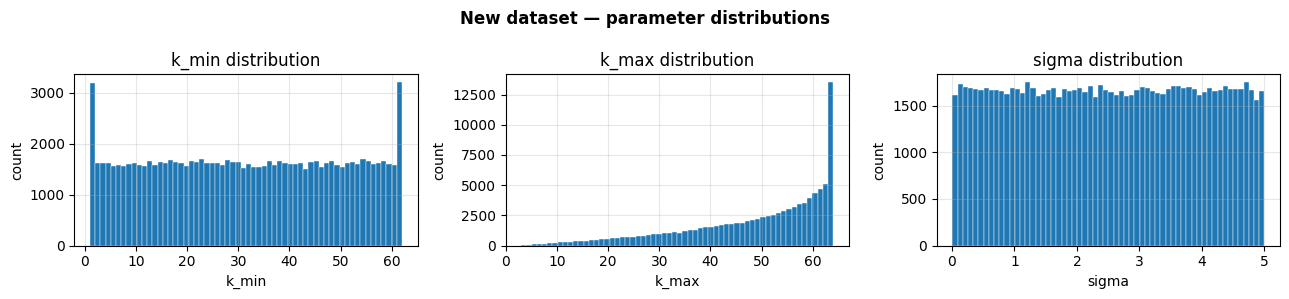

In [11]:
# Cell 3 — Verify dataset: confirm uniform k_min distribution
with h5py.File(DATA_FILE, 'r') as hf:
    kmin  = hf['parameters']['k_min'][:]
    kmax  = hf['parameters']['k_max'][:]
    sigma = hf['parameters']['sigma'][:]
    n     = hf['images'].shape[0]

print(f'N = {n:,}')
print(f'k_min : [{kmin.min():.0f}, {kmin.max():.0f}]  mean={kmin.mean():.1f}')
print(f'k_max : [{kmax.min():.0f}, {kmax.max():.0f}]  mean={kmax.mean():.1f}')
print(f'sigma : [{sigma.min():.3f}, {sigma.max():.3f}]  mean={sigma.mean():.3f}')
print(f'k_min/k_max correlation: {np.corrcoef(kmin, kmax)[0,1]:.3f}')

print('\nk_min distribution:')
bins = [1, 10, 20, 30, 40, 50, 63]
hist, _ = np.histogram(kmin, bins=bins)
for i in range(len(hist)):
    bar = '█' * int(hist[i] / n * 500)
    print(f'  [{bins[i]:2d}–{bins[i+1]-1:2d}]  {hist[i]:6,} ({100*hist[i]/n:5.1f}%)  {bar}')

fig, axes = plt.subplots(1, 3, figsize=(13, 3))
for ax, vals, label in zip(axes,
                           [kmin, kmax, sigma],
                           ['k_min', 'k_max', 'sigma']):
    ax.hist(vals, bins=60, edgecolor='white', linewidth=0.3)
    ax.set_xlabel(label); ax.set_ylabel('count')
    ax.set_title(f'{label} distribution')
    ax.grid(True, alpha=0.3)
plt.suptitle('New dataset — parameter distributions', fontweight='bold')
plt.tight_layout()
plt.show()

In [12]:
# Cell 4 — Global image percentiles (computed once from 2K subsample)
np.random.seed(SEED)
samp_size = 2000

with h5py.File(DATA_FILE, 'r') as hf:
    n_total  = hf['images'].shape[0]
    samp_idx = np.sort(np.random.choice(n_total, size=samp_size, replace=False))
    samp     = hf['images'][samp_idx]       # (2000, 128, 128)

IMG_P1  = float(np.percentile(samp, 1))
IMG_P99 = float(np.percentile(samp, 99))
del samp

print(f'Global image percentiles:  p1={IMG_P1:.4f}  p99={IMG_P99:.4f}')
print(f'Log-sigma range:           [{LOG_SIG_LO:.4f}, {LOG_SIG_HI:.4f}]')

Global image percentiles:  p1=-2.0818  p99=0.9409
Log-sigma range:           [-4.6052, 1.6094]


In [13]:
# Cell 5 — JointHDF5Dataset and data splits

class JointHDF5Dataset(Dataset):
    """
    Loads images with global p1/p99 normalisation (preserves contrast for sigma).
    Returns labels as (3,) tensor: [k_min_norm, k_max_norm, log_sigma_norm] in [0,1].
    """
    def __init__(self, h5_path, indices, kmin_vals, kmax_vals, sigma_vals,
                 img_p1, img_p99):
        self.h5_path   = str(h5_path)
        self.indices   = indices
        self.img_p1    = float(img_p1)
        self.img_range = float(img_p99 - img_p1) + 1e-8

        kmin_n  = (kmin_vals[indices]  - KMIN_LO)   / (KMIN_HI  - KMIN_LO)
        kmax_n  = (kmax_vals[indices]  - KMAX_LO)   / (KMAX_HI  - KMAX_LO)
        log_sig = np.log(np.clip(sigma_vals[indices].astype(np.float64), 1e-9, None))
        sig_n   = (log_sig - LOG_SIG_LO) / (LOG_SIG_HI - LOG_SIG_LO)

        self.labels = np.stack(
            [kmin_n, kmax_n, sig_n], axis=1
        ).astype(np.float32)   # (N, 3)
        self._h5 = None

    def _get_h5(self):
        if self._h5 is None:
            self._h5 = h5py.File(self.h5_path, 'r')
        return self._h5

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        img = self._get_h5()['images'][self.indices[idx]].astype(np.float32)
        img = (img - self.img_p1) / self.img_range
        img = img[np.newaxis]                                  # (1, H, W)
        return torch.from_numpy(img), torch.from_numpy(self.labels[idx])

    def __del__(self):
        if self._h5 is not None:
            self._h5.close()


# Build splits
with h5py.File(DATA_FILE, 'r') as hf:
    n_total    = hf['images'].shape[0]
    kmin_vals  = hf['parameters']['k_min'][:]
    kmax_vals  = hf['parameters']['k_max'][:]
    sigma_vals = hf['parameters']['sigma'][:]

indices = np.arange(n_total)
train_idx, tmp      = train_test_split(indices, test_size=0.2,  random_state=SEED)
val_idx,   test_idx = train_test_split(tmp,     test_size=0.5,  random_state=SEED)

ds_kwargs = dict(kmin_vals=kmin_vals, kmax_vals=kmax_vals, sigma_vals=sigma_vals,
                 img_p1=IMG_P1, img_p99=IMG_P99)
train_ds = JointHDF5Dataset(DATA_FILE, train_idx, **ds_kwargs)
val_ds   = JointHDF5Dataset(DATA_FILE, val_idx,   **ds_kwargs)
test_ds  = JointHDF5Dataset(DATA_FILE, test_idx,  **ds_kwargs)

loader_kw    = dict(batch_size=BATCH_SIZE, num_workers=0, pin_memory=True)
train_loader = DataLoader(train_ds, shuffle=True,  **loader_kw)
val_loader   = DataLoader(val_ds,   shuffle=False, **loader_kw)
test_loader  = DataLoader(test_ds,  shuffle=False, **loader_kw)

print(f'Train: {len(train_ds):,}  Val: {len(val_ds):,}  Test: {len(test_ds):,}')

Train: 80,000  Val: 10,000  Test: 10,000


In [14]:
# Cell 6 — ResNet50 with 3-output Sigmoid head

class ResNet50Joint(nn.Module):
    """ResNet50 backbone with shared features and a 3-output Sigmoid regression head."""
    def __init__(self, in_channels=1, n_outputs=3):
        super().__init__()
        self.backbone = models.resnet50(weights=None)
        self.backbone.conv1 = nn.Conv2d(
            in_channels, 64, kernel_size=7, stride=2, padding=3, bias=False)
        in_feats = self.backbone.fc.in_features
        self.backbone.fc = nn.Sequential(
            nn.Linear(in_feats, 256), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(256, 64),       nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(64, n_outputs),
            nn.Sigmoid()              # bounds all outputs to [0, 1]
        )

    def forward(self, x):
        return self.backbone(x)       # (B, 3)


n_params = sum(p.numel() for p in ResNet50Joint().parameters())
print(f'ResNet50Joint params: {n_params:,}')

ResNet50Joint params: 24,042,947


In [15]:
# Cell 7 — Joint RMSE loss, train / eval helpers, and denorm

class JointRMSELoss(nn.Module):
    """Sum of per-output RMSE on normalised [0,1] targets (equal weight)."""
    def __init__(self, eps=1e-8):
        super().__init__()
        self.eps = eps

    def forward(self, pred, target):
        diff = pred - target                           # (B, 3)
        mse  = diff.pow(2).mean(dim=0)                 # (3,)
        return torch.sqrt(mse + self.eps).sum()        # scalar


def train_epoch(model, loader, criterion, optimizer, scaler, device):
    model.train()
    total = 0.0
    for X, y in loader:
        X, y = X.to(device), y.to(device)
        optimizer.zero_grad()
        if scaler:
            with torch.amp.autocast('cuda'):
                loss = criterion(model(X), y)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            loss = criterion(model(X), y)
            loss.backward()
            optimizer.step()
        total += loss.item() * len(X)
    return total / len(loader.dataset)


@torch.no_grad()
def eval_epoch(model, loader, criterion, device):
    model.eval()
    total, preds, targets = 0.0, [], []
    for X, y in loader:
        X, y = X.to(device), y.to(device)
        pred  = model(X)
        total += criterion(pred, y).item() * len(X)
        preds.append(pred.cpu())
        targets.append(y.cpu())
    preds   = torch.cat(preds).numpy()    # (N, 3)
    targets = torch.cat(targets).numpy()  # (N, 3)
    mae_per_output = np.mean(np.abs(preds - targets), axis=0)  # (3,)
    return total / len(loader.dataset), mae_per_output, preds, targets


def denorm(preds_norm, targets_norm):
    """Convert normalised [0,1] predictions back to original parameter scales."""
    p_kmin = preds_norm[:, 0]  * (KMIN_HI - KMIN_LO)  + KMIN_LO
    p_kmax = preds_norm[:, 1]  * (KMAX_HI - KMAX_LO)  + KMAX_LO
    p_sig  = np.exp(preds_norm[:, 2]  * (LOG_SIG_HI - LOG_SIG_LO) + LOG_SIG_LO)

    t_kmin = targets_norm[:, 0] * (KMIN_HI - KMIN_LO)  + KMIN_LO
    t_kmax = targets_norm[:, 1] * (KMAX_HI - KMAX_LO)  + KMAX_LO
    t_sig  = np.exp(targets_norm[:, 2] * (LOG_SIG_HI - LOG_SIG_LO) + LOG_SIG_LO)

    return ({'k_min': p_kmin, 'k_max': p_kmax, 'sigma': p_sig},
            {'k_min': t_kmin, 'k_max': t_kmax, 'sigma': t_sig})


print('Loss, helpers, and denorm defined.')

Loss, helpers, and denorm defined.


Smoke test: 2000 train / 500 val / 500 test  |  5 epochs
  Ep 1/5 | train 0.6231 | val 0.4795 | mae kmin=0.1680 kmax=0.1552 sig=0.0480
  Ep 2/5 | train 0.4359 | val 0.3314 | mae kmin=0.0818 kmax=0.1471 sig=0.0351
  Ep 3/5 | train 0.3885 | val 0.3751 | mae kmin=0.0864 kmax=0.1559 sig=0.0438
  Ep 4/5 | train 0.3953 | val 0.2922 | mae kmin=0.0526 kmax=0.1381 sig=0.0290
  Ep 5/5 | train 0.3750 | val 0.3675 | mae kmin=0.1074 kmax=0.1493 sig=0.0348

Time per epoch (smoke): 5.4s
Estimated full training (50 epochs x 80,000 samples): ~179 min

--- Smoke test metrics (original units) ---
  k_min     MAE=6.213  R²=0.8134
  k_max     MAE=9.492  R²=0.2561
  sigma     MAE=0.403  R²=0.8664


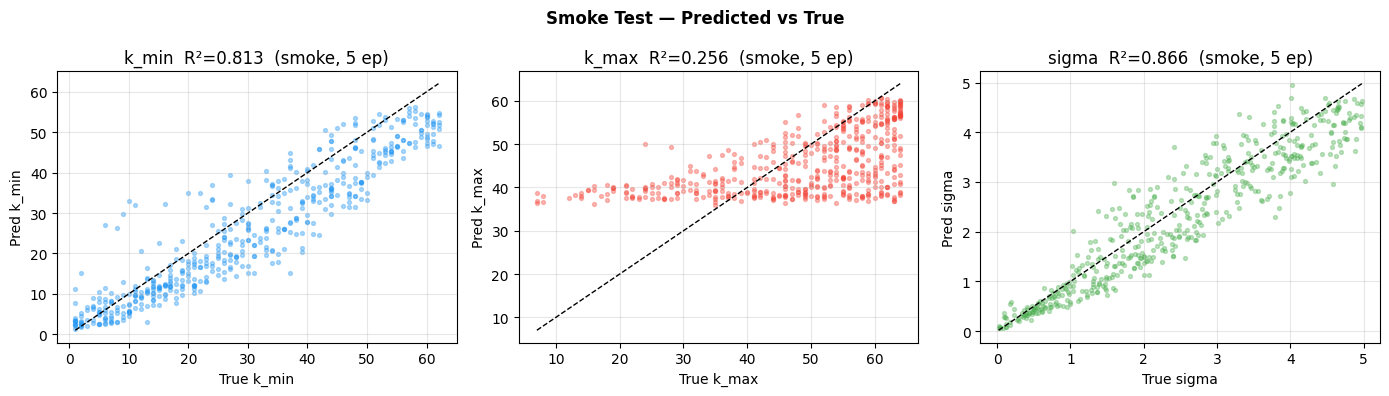

In [16]:
# Cell 8 — Smoke test: 2K images, 5 epochs (~2-3 min)
# Runs a mini version of the full pipeline to confirm everything works
# before committing to the full training run.
# Results are printed but NOT saved — does not affect Cell 9 onwards.

from torch.utils.data import Subset

SMOKE_TRAIN  = 2000
SMOKE_VAL    = 500
SMOKE_TEST   = 500
SMOKE_EPOCHS = 5

rng = np.random.RandomState(SEED)
smoke_train_ds = Subset(train_ds, rng.choice(len(train_ds), SMOKE_TRAIN, replace=False))
smoke_val_ds   = Subset(val_ds,   rng.choice(len(val_ds),   SMOKE_VAL,   replace=False))
smoke_test_ds  = Subset(test_ds,  rng.choice(len(test_ds),  SMOKE_TEST,  replace=False))

smoke_kw = dict(batch_size=BATCH_SIZE, num_workers=0, pin_memory=True)
smoke_train_loader = DataLoader(smoke_train_ds, shuffle=True,  **smoke_kw)
smoke_val_loader   = DataLoader(smoke_val_ds,   shuffle=False, **smoke_kw)
smoke_test_loader  = DataLoader(smoke_test_ds,  shuffle=False, **smoke_kw)

smoke_model     = ResNet50Joint(in_channels=1).to(DEVICE)
smoke_criterion = JointRMSELoss().to(DEVICE)
smoke_optimizer = optim.AdamW(smoke_model.parameters(), lr=LR, weight_decay=1e-4)
smoke_scaler    = torch.amp.GradScaler("cuda") if DEVICE.type == "cuda" else None

print(f"Smoke test: {SMOKE_TRAIN} train / {SMOKE_VAL} val / {SMOKE_TEST} test  |  {SMOKE_EPOCHS} epochs")
smoke_t0 = time.time()

for ep in range(SMOKE_EPOCHS):
    tl           = train_epoch(smoke_model, smoke_train_loader, smoke_criterion,
                               smoke_optimizer, smoke_scaler, DEVICE)
    vl, vm, _, _ = eval_epoch(smoke_model, smoke_val_loader, smoke_criterion, DEVICE)
    print(f"  Ep {ep+1}/{SMOKE_EPOCHS} | train {tl:.4f} | val {vl:.4f}"
          f" | mae kmin={vm[0]:.4f} kmax={vm[1]:.4f} sig={vm[2]:.4f}")

ep_time = (time.time() - smoke_t0) / SMOKE_EPOCHS
print(f"\nTime per epoch (smoke): {ep_time:.1f}s")
print(f"Estimated full training ({EPOCHS} epochs x {len(train_ds):,} samples):"
      f" ~{ep_time * EPOCHS * len(train_ds) / SMOKE_TRAIN / 60:.0f} min")

# Quick eval on smoke test set
_, _, s_pred_n, s_true_n = eval_epoch(smoke_model, smoke_test_loader,
                                       smoke_criterion, DEVICE)
s_pred, s_true = denorm(s_pred_n, s_true_n)

print("\n--- Smoke test metrics (original units) ---")
for param in ["k_min", "k_max", "sigma"]:
    mae = float(mean_absolute_error(s_true[param], s_pred[param]))
    r2  = float(r2_score(s_true[param], s_pred[param]))
    print(f"  {param:<8}  MAE={mae:.3f}  R²={r2:.4f}")

# Quick scatter
smoke_colors = {"k_min": "#2196F3", "k_max": "#F44336", "sigma": "#4CAF50"}
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, param in zip(axes, ["k_min", "k_max", "sigma"]):
    yt, yp = s_true[param], s_pred[param]
    r2 = float(r2_score(yt, yp))
    ax.scatter(yt, yp, alpha=0.35, s=8, color=smoke_colors[param])
    lims = [min(yt.min(), yp.min()), max(yt.max(), yp.max())]
    ax.plot(lims, lims, "k--", linewidth=1)
    ax.set_xlabel(f"True {param}"); ax.set_ylabel(f"Pred {param}")
    ax.set_title(f"{param}  R²={r2:.3f}  (smoke, {SMOKE_EPOCHS} ep)")
    ax.grid(True, alpha=0.3)
plt.suptitle("Smoke Test — Predicted vs True", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

del smoke_model, smoke_optimizer, smoke_scaler
if torch.cuda.is_available(): torch.cuda.empty_cache()

In [17]:
# Cell 8 — Training loop (resume-safe: skips if results.json exists)
results_path = OUTPUT_DIR / 'results.json'

if results_path.exists():
    print(f'[SKIP] results.json already exists — jump to Cell 9 to load results')
else:
    model     = ResNet50Joint(in_channels=1).to(DEVICE)
    criterion = JointRMSELoss().to(DEVICE)
    optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=5, min_lr=1e-7)
    scaler    = torch.amp.GradScaler('cuda') if DEVICE.type == 'cuda' else None

    history       = {'train_loss': [], 'val_loss': [],
                     'val_mae_kmin': [], 'val_mae_kmax': [], 'val_mae_sigma': []}
    best_val_loss = float('inf')
    best_ckpt     = OUTPUT_DIR / 'best_model.pt'
    run_start     = time.time()

    TARGET_NAMES = ['k_min', 'k_max', 'sigma']

    for epoch in range(EPOCHS):
        tl                      = train_epoch(model, train_loader, criterion, optimizer, scaler, DEVICE)
        vl, val_mae, _, _       = eval_epoch(model, val_loader,   criterion, DEVICE)
        scheduler.step(vl)

        history['train_loss'].append(float(tl))
        history['val_loss'].append(float(vl))
        history['val_mae_kmin'].append(float(val_mae[0]))
        history['val_mae_kmax'].append(float(val_mae[1]))
        history['val_mae_sigma'].append(float(val_mae[2]))

        lr = optimizer.param_groups[0]['lr']
        print(f'Ep {epoch+1:2d}/{EPOCHS} | train {tl:.4f} | val {vl:.4f} '
              f'| mae kmin={val_mae[0]:.4f} kmax={val_mae[1]:.4f} sig={val_mae[2]:.4f} '
              f'| lr {lr:.1e}')

        if vl < best_val_loss:
            best_val_loss = vl
            torch.save(model.state_dict(), best_ckpt)

    print(f'\nTraining done in {(time.time()-run_start)/60:.1f} min')
    print(f'Best val loss: {best_val_loss:.4f}')

Ep  1/50 | train 0.3260 | val 0.2148 | mae kmin=0.0317 kmax=0.1052 sig=0.0166 | lr 1.0e-04
Ep  2/50 | train 0.2640 | val 0.2140 | mae kmin=0.0293 kmax=0.0997 sig=0.0137 | lr 1.0e-04
Ep  3/50 | train 0.2465 | val 0.2051 | mae kmin=0.0284 kmax=0.0969 sig=0.0171 | lr 1.0e-04
Ep  4/50 | train 0.2316 | val 0.1840 | mae kmin=0.0198 kmax=0.0935 sig=0.0127 | lr 1.0e-04
Ep  5/50 | train 0.2195 | val 0.2217 | mae kmin=0.0219 kmax=0.1033 sig=0.0170 | lr 1.0e-04
Ep  6/50 | train 0.2109 | val 0.2178 | mae kmin=0.0283 kmax=0.0917 sig=0.0131 | lr 1.0e-04
Ep  7/50 | train 0.2028 | val 0.1784 | mae kmin=0.0190 kmax=0.0862 sig=0.0117 | lr 1.0e-04
Ep  8/50 | train 0.1981 | val 0.2024 | mae kmin=0.0276 kmax=0.0895 sig=0.0145 | lr 1.0e-04
Ep  9/50 | train 0.1926 | val 0.1944 | mae kmin=0.0216 kmax=0.0871 sig=0.0105 | lr 1.0e-04
Ep 10/50 | train 0.1877 | val 0.1627 | mae kmin=0.0164 kmax=0.0820 sig=0.0085 | lr 1.0e-04
Ep 11/50 | train 0.1838 | val 0.2351 | mae kmin=0.0328 kmax=0.0967 sig=0.0127 | lr 1.0e-04

Using in-memory `history` (results.json not found).


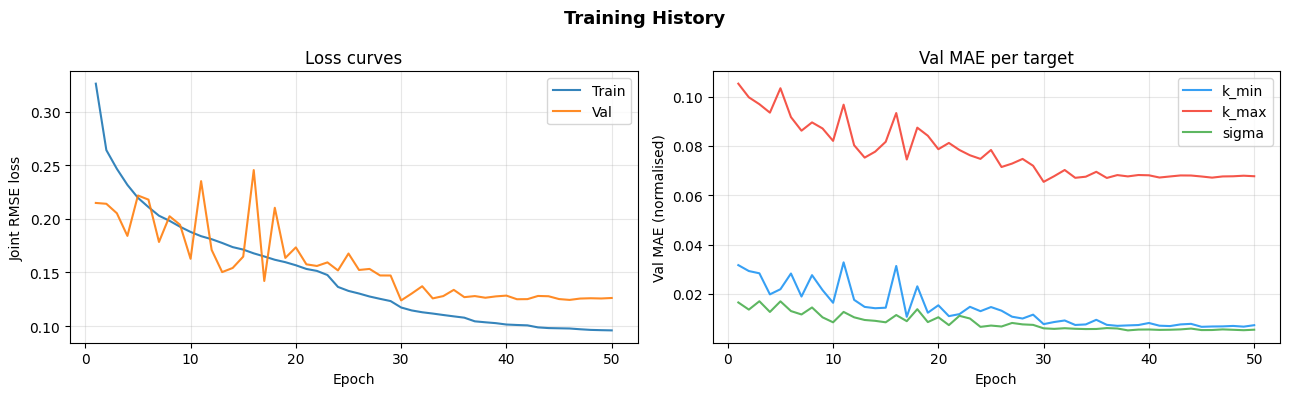

In [19]:
# Cell 10 — Training curves
if 'results' not in globals():
    rp = results_path if 'results_path' in globals() else (OUTPUT_DIR / 'results.json')
    if rp.exists():
        with open(rp, 'r') as f:
            results = json.load(f)
        print(f'Loaded results from: {rp}')
    elif 'history' in globals():
        results = {'history': history}
        print('Using in-memory `history` (results.json not found).')
    else:
        raise RuntimeError(
            "No `results` available. Run the training/evaluation cell first, "
            "or ensure results.json exists."
        )

h = results['history']
epochs_range = range(1, len(h['train_loss']) + 1)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(epochs_range, h['train_loss'], label='Train', alpha=0.9)
axes[0].plot(epochs_range, h['val_loss'],   label='Val',   alpha=0.9)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Joint RMSE loss')
axes[0].set_title('Loss curves'); axes[0].legend(); axes[0].grid(True, alpha=0.3)

colors = {'k_min': '#2196F3', 'k_max': '#F44336', 'sigma': '#4CAF50'}
for param, key in [('k_min', 'val_mae_kmin'),
                   ('k_max', 'val_mae_kmax'),
                   ('sigma', 'val_mae_sigma')]:
    if key in h:
        axes[1].plot(epochs_range, h[key], label=param,
                     color=colors[param], alpha=0.9)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Val MAE (normalised)')
axes[1].set_title('Val MAE per target'); axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.suptitle('Training History', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

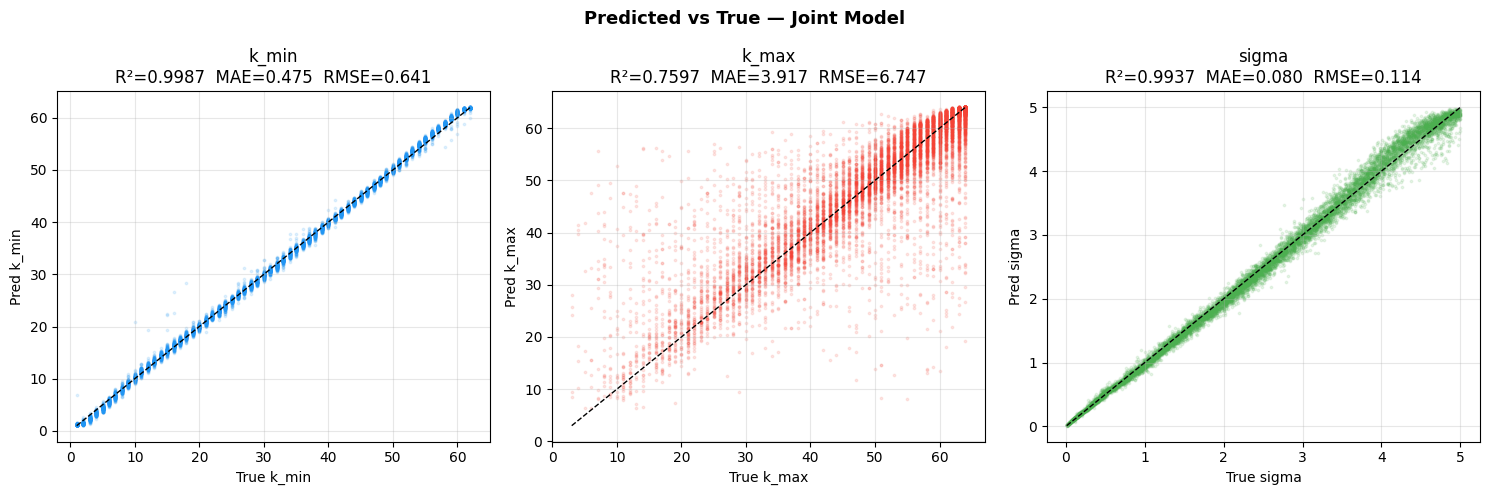

In [21]:
# Cell 11 — Predicted vs True scatter plots
params      = ['k_min', 'k_max', 'sigma']
param_units = {'k_min': 'wavenumber', 'k_max': 'wavenumber', 'sigma': ''}

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, param in zip(axes, params):
    if 'y_true' not in results or 'y_pred' not in results:
        if 'test_loader' not in globals() or 'model' not in globals():
            raise KeyError("results does not contain y_true/y_pred, and no test evaluation is available")
        if 'best_ckpt' in globals() and best_ckpt.exists():
            model.load_state_dict(torch.load(best_ckpt, map_location=DEVICE))
        _, _, y_pred_n, y_true_n = eval_epoch(model, test_loader, criterion, DEVICE)
        y_pred_d, y_true_d = denorm(y_pred_n, y_true_n)
        results['y_true'] = y_true_d
        results['y_pred'] = y_pred_d
        results['metrics'] = {
            p: {
                'mae': float(mean_absolute_error(y_true_d[p], y_pred_d[p])),
                'rmse': float(np.sqrt(mean_squared_error(y_true_d[p], y_pred_d[p]))),
                'r2': float(r2_score(y_true_d[p], y_pred_d[p])),
            }
            for p in params
        }
    yt = np.array(results['y_true'][param])
    yp = np.array(results['y_pred'][param])
    m  = results['metrics'][param]

    ax.scatter(yt, yp, alpha=0.12, s=3, color=colors[param], rasterized=True)
    lims = [min(yt.min(), yp.min()), max(yt.max(), yp.max())]
    ax.plot(lims, lims, 'k--', linewidth=1)
    ax.set_xlabel(f'True {param}'); ax.set_ylabel(f'Pred {param}')
    ax.set_title(f'{param}\nR²={m["r2"]:.4f}  MAE={m["mae"]:.3f}  RMSE={m["rmse"]:.3f}')
    ax.grid(True, alpha=0.3)

plt.suptitle('Predicted vs True — Joint Model', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'scatter.png', dpi=150, bbox_inches='tight')
plt.show()

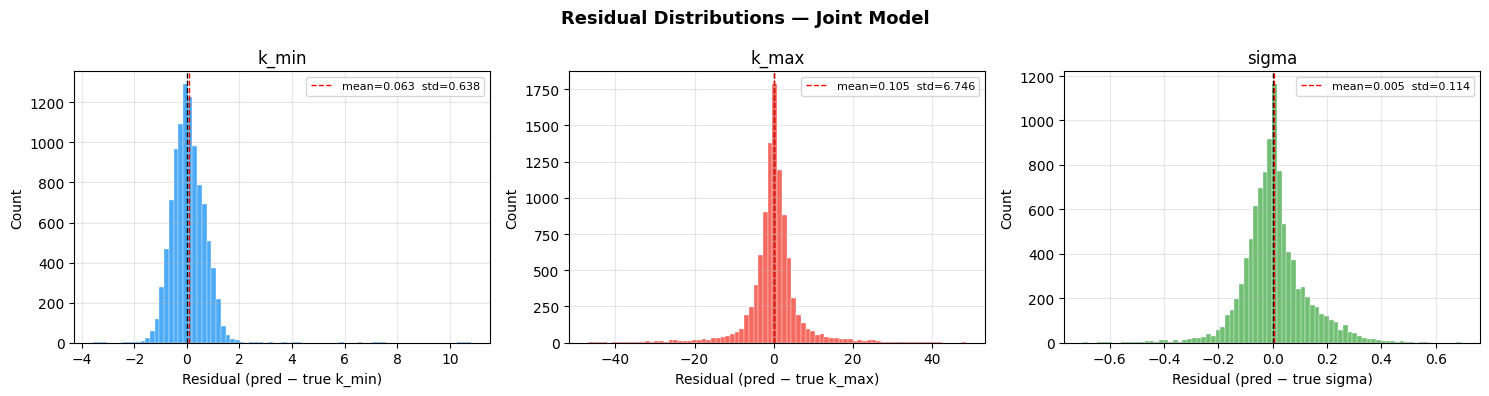

In [22]:
# Cell 12 — Residual distributions
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, param in zip(axes, params):
    yt  = np.array(results['y_true'][param])
    yp  = np.array(results['y_pred'][param])
    res = yp - yt

    ax.hist(res, bins=80, color=colors[param], alpha=0.8, edgecolor='white', linewidth=0.3)
    ax.axvline(0,        color='black', linestyle='--', linewidth=1)
    ax.axvline(res.mean(), color='red', linestyle='--', linewidth=1,
               label=f'mean={res.mean():.3f}  std={res.std():.3f}')
    ax.set_xlabel(f'Residual (pred − true {param})')
    ax.set_ylabel('Count')
    ax.set_title(param)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle('Residual Distributions — Joint Model', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'residuals.png', dpi=150, bbox_inches='tight')
plt.show()

In [23]:
# Cell 13 — Summary table
print(f"\n{'='*52}")
print(f"Joint ResNet50 — test set performance")
print(f"Dataset: {DATA_FILE.name}")
t_min = results.get('training_time_min')
if t_min:
    print(f"Training time: {t_min:.1f} min")
print(f"{'='*52}")
print(f"{'PARAM':<8} {'MAE':>8} {'RMSE':>8} {'R²':>8}")
print(f"{'-'*52}")
for param, m in results['metrics'].items():
    print(f"{param:<8} {m['mae']:>8.3f} {m['rmse']:>8.3f} {m['r2']:>8.4f}")
print(f"{'='*52}")

# Range-normalised MAE (% of parameter range) for interpretability
ranges = {'k_min': KMIN_HI - KMIN_LO, 'k_max': KMAX_HI - KMAX_LO,
          'sigma': np.exp(LOG_SIG_HI) - np.exp(LOG_SIG_LO)}
print(f"\nNormalised MAE (% of range):")
for param, m in results['metrics'].items():
    pct = 100 * m['mae'] / ranges[param]
    print(f"  {param:<8}  {pct:.1f}%")


Joint ResNet50 — test set performance
Dataset: uniform_kmin_128x128_100000.h5
PARAM         MAE     RMSE       R²
----------------------------------------------------
k_min       0.475    0.641   0.9987
k_max       3.917    6.747   0.7597
sigma       0.080    0.114   0.9937

Normalised MAE (% of range):
  k_min     0.8%
  k_max     6.6%
  sigma     1.6%
